# LiteDiseaseNetV4 — V3 with every upgrade area applied

MobileNetV2 dual-branch model, trained on the **cleaned split from Part A of
`crop_disease_pipeline.ipynb`** (reads `crop-disease/manifest_clean.csv`; run that
notebook first if it is missing).

| Area | V3 | V4 (this notebook) |
|---|---|---|
| Texture branch | SE + pool on raw 32ch@28x28 | small conv bottleneck 32->64->96 + CBAM |
| Semantic refine | 1 ResidualSEBlock | 2 residual blocks with CBAM |
| Attention | SE (channel only) | CBAM: channel + spatial |
| Fusion | plain concat (1312) | learned per-image gate over the two branches |
| Classifier | 1312 -> 512 -> classes | 1376 -> 768 -> classes |
| Backbone LR | 1e-5 | 3e-5 |
| Epochs | 25 | 25 |
| Label smoothing | 0.1 | 0.1 |

Backbone stays `mobilenet_v2`, split at `features[:7]` (32ch@28x28) — the backbone swap
is a separate, bigger experiment.

Outputs use the `litedisease_v4_` prefix so the team's seven-way `results_*.json`
collection is not polluted with a run that uses a different recipe.

In [1]:
# ---- config ---------------------------------------------------------------- #
SEED, EPOCHS, BATCH_SIZE, IMG_SIZE = 42, 25, 32, 224
LR_BACKBONE, LR_HEAD = 3e-5, 3e-4
LABEL_SMOOTHING, WEIGHT_DECAY = 0.1, 1e-4
USE_CLASS_WEIGHTS, USE_AMP = True, True

import json, os, random, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from tqdm.auto import tqdm

OUT_DIR = Path.cwd() / "crop-disease"
MANIFEST = OUT_DIR / "manifest_clean.csv"
assert MANIFEST.is_file(), "manifest_clean.csv missing - run crop_disease_pipeline.ipynb Part A first"

def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ON = USE_AMP and DEVICE.type == "cuda"
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

clean = pd.read_csv(MANIFEST)
clean = clean[clean["status"] == "ok"] if "status" in clean else clean
CLASS_NAMES = sorted(clean["class_raw"].unique())
N_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

# stored absolute paths may be stale if data was re-extracted - remap by filename
if not all(Path(p).is_file() for p in clean["path"].head(50)):
    index = {}
    for dirpath, dirnames, filenames in os.walk(OUT_DIR / "raw"):
        for f in filenames:
            index.setdefault(f, str(Path(dirpath) / f))
    clean = clean.assign(path=[index[f] for f in clean["filename"]])
    print("remapped stale image paths")

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.0, hue=0.0),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(round(IMG_SIZE * 8 / 7)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class ManifestDataset(Dataset):
    def __init__(self, frame, transform):
        self.samples = [(r.path, CLASS_TO_IDX[r.class_raw])
                        for r in frame.itertuples(index=False)]
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        path, label = self.samples[i]
        with Image.open(path) as im:
            img = im.convert("RGB")
        return self.transform(img), label

parts = {s: clean[clean["split"] == s].reset_index(drop=True)
         for s in ("train", "val", "test")}
NUM_WORKERS = 0 if os.name == "nt" else 2      # Windows: notebook classes can't spawn
PIN = DEVICE.type == "cuda"
GEN = torch.Generator(); GEN.manual_seed(SEED)

def make_loader(frame, tf, shuffle):
    return DataLoader(ManifestDataset(frame, tf), batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=PIN, generator=GEN)

train_loader = make_loader(parts["train"], train_tf, True)
train_eval_loader = make_loader(parts["train"], eval_tf, False)
val_loader = make_loader(parts["val"], eval_tf, False)
test_loader = make_loader(parts["test"], eval_tf, False)

cw = json.loads((OUT_DIR / "class_weights.json").read_text())
CLASS_WEIGHTS = (torch.tensor([cw[c] for c in CLASS_NAMES], dtype=torch.float32)
                 .to(DEVICE) if USE_CLASS_WEIGHTS else None)

print(f"device {DEVICE.type} | train {len(parts['train'])} val {len(parts['val'])} "
      f"test {len(parts['test'])} | {N_CLASSES} classes | workers {NUM_WORKERS}")

C:\Users\Welcome\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device cuda | train 14434 val 3096 test 3092 | 15 classes | workers 0


In [2]:
# ---- model: LiteDiseaseNetV4 ----------------------------------------------- #
class ChannelAttention(nn.Module):
    """CBAM channel attention: shared MLP over avg- and max-pooled descriptors."""
    def __init__(self, ch, reduction=16):
        super().__init__()
        hidden = max(ch // reduction, 8)
        self.mlp = nn.Sequential(nn.Linear(ch, hidden), nn.ReLU(inplace=True),
                                 nn.Linear(hidden, ch))
    def forward(self, x):
        b, c, _, _ = x.shape
        avg = self.mlp(x.mean(dim=(2, 3)))
        mx = self.mlp(x.amax(dim=(2, 3)))
        return x * torch.sigmoid(avg + mx).view(b, c, 1, 1)

class SpatialAttention(nn.Module):
    """CBAM spatial attention: 7x7 conv over channel-avg and channel-max maps."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
    def forward(self, x):
        m = torch.cat([x.mean(dim=1, keepdim=True), x.amax(dim=1, keepdim=True)], dim=1)
        return x * torch.sigmoid(self.conv(m))

class CBAM(nn.Module):
    def __init__(self, ch, reduction=16):
        super().__init__()
        self.channel = ChannelAttention(ch, reduction)
        self.spatial = SpatialAttention()
    def forward(self, x):
        return self.spatial(self.channel(x))

class ResidualCBAMBlock(nn.Module):
    """Bottleneck refine block with CBAM, residual add. Replaces V3's ResidualSEBlock."""
    def __init__(self, ch, bottleneck=192):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(ch, bottleneck, 1, bias=False), nn.BatchNorm2d(bottleneck),
            nn.ReLU(inplace=True),
            nn.Conv2d(bottleneck, bottleneck, 3, padding=1, bias=False),
            nn.BatchNorm2d(bottleneck), nn.ReLU(inplace=True),
            nn.Conv2d(bottleneck, ch, 1, bias=False), nn.BatchNorm2d(ch),
        )
        self.attn = CBAM(ch)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.act(x + self.attn(self.body(x)))

class LiteDiseaseNetV4(nn.Module):
    TEX_CH, SEM_CH, HIDDEN = 96, 1280, 768

    def __init__(self, n_classes, pretrained=True):
        super().__init__()
        weights = MobileNet_V2_Weights.DEFAULT if pretrained else None
        layers = mobilenet_v2(weights=weights).features
        self.stem = layers[:7]                 # 32ch @ 28x28 - texture branch input
        self.stage2 = layers[7:]               # -> 1280ch @ 7x7 - semantic branch

        # texture branch: was SE + pool on raw features; now a small conv bottleneck
        self.texture = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, self.TEX_CH, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(self.TEX_CH), nn.ReLU(inplace=True),
            CBAM(self.TEX_CH),
        )
        # semantic refine: 2 blocks (V3 had 1)
        self.refine = nn.Sequential(ResidualCBAMBlock(self.SEM_CH),
                                    ResidualCBAMBlock(self.SEM_CH))
        self.pool = nn.AdaptiveAvgPool2d(1)
        # learned fusion gate: per-image weights for the two branches
        self.gate = nn.Linear(self.SEM_CH + self.TEX_CH, 2)
        self.classifier = nn.Sequential(
            nn.Linear(self.SEM_CH + self.TEX_CH, self.HIDDEN),
            nn.BatchNorm1d(self.HIDDEN), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(self.HIDDEN, n_classes),
        )

    def forward(self, x):
        low = self.stem(x)
        tex = self.pool(self.texture(low)).flatten(1)          # B x 96
        sem = self.pool(self.refine(self.stage2(low))).flatten(1)   # B x 1280
        both = torch.cat([sem, tex], dim=1)                    # B x 1376
        g = torch.softmax(self.gate(both), dim=1)              # B x 2
        fused = torch.cat([sem * (2 * g[:, :1]), tex * (2 * g[:, 1:])], dim=1)
        return self.classifier(fused)

    def backbone_parameters(self):
        return [p for m in (self.stem, self.stage2) for p in m.parameters()]

    def head_parameters(self):
        return [p for m in (self.texture, self.refine, self.gate, self.classifier)
                for p in m.parameters()]

MODEL = LiteDiseaseNetV4(N_CLASSES).to(DEVICE)
n_total = sum(p.numel() for p in MODEL.parameters())
n_backbone = sum(p.numel() for p in MODEL.backbone_parameters())
print(f"LiteDiseaseNetV4: {n_total:,} params "
      f"(backbone {n_backbone:,}, new modules {n_total - n_backbone:,})")
with torch.no_grad():
    out = MODEL(torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE))
assert out.shape == (2, N_CLASSES), out.shape
print("forward pass OK", tuple(out.shape))

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\Welcome/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth



  0%|          | 0.00/13.6M [00:00<?, ?B/s]


 11%|█         | 1.50M/13.6M [00:00<00:00, 14.7MB/s]


 23%|██▎       | 3.12M/13.6M [00:00<00:00, 15.7MB/s]


 36%|███▌      | 4.88M/13.6M [00:00<00:00, 16.3MB/s]

...


 87%|████████▋ | 11.9M/13.6M [00:00<00:00, 16.5MB/s]


100%|██████████| 13.6M/13.6M [00:00<00:00, 16.7MB/s]


100%|██████████| 13.6M/13.6M [00:00<00:00, 16.6MB/s]

LiteDiseaseNetV4: 5,438,786 params (backbone 2,223,872, new modules 3,214,914)


forward pass OK (2, 15)


In [3]:
# ---- train ------------------------------------------------------------------ #
CRITERION = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS, label_smoothing=LABEL_SMOOTHING)
OPTIMIZER = torch.optim.AdamW(
    [{"params": MODEL.backbone_parameters(), "lr": LR_BACKBONE},
     {"params": MODEL.head_parameters(), "lr": LR_HEAD}],
    weight_decay=WEIGHT_DECAY)
SCHEDULER = torch.optim.lr_scheduler.ReduceLROnPlateau(
    OPTIMIZER, mode="max", factor=0.5, patience=3)
SCALER = torch.amp.GradScaler(enabled=AMP_ON)

LOG_PATH = OUT_DIR / "litedisease_v4_log.csv"
BEST_PATH = OUT_DIR / "litedisease_v4_best.pth"

def run_epoch(model, loader, optimizer=None, desc=""):
    training = optimizer is not None
    model.train(training)
    tot_loss = n_seen = 0
    preds, targets = [], []
    for x, y in tqdm(loader, desc=desc, leave=False, unit="b"):
        x, y = x.to(DEVICE, non_blocking=PIN), y.to(DEVICE, non_blocking=PIN)
        with torch.set_grad_enabled(training):
            with torch.autocast(DEVICE.type, enabled=AMP_ON):
                out = model(x)
                loss = CRITERION(out, y)
        if training:
            optimizer.zero_grad(set_to_none=True)
            SCALER.scale(loss).backward()
            SCALER.step(optimizer)
            SCALER.update()
        tot_loss += loss.item() * len(y)
        n_seen += len(y)
        preds.append(out.argmax(1).cpu())
        targets.append(y.cpu())
    preds, targets = torch.cat(preds).numpy(), torch.cat(targets).numpy()
    p, r, f1, _ = precision_recall_fscore_support(
        targets, preds, average="macro", zero_division=0)
    return {"loss": tot_loss / n_seen, "accuracy": accuracy_score(targets, preds),
            "macro_precision": p, "macro_recall": r, "macro_f1": f1,
            "n": n_seen, "preds": preds, "targets": targets}

best = {"epoch": 0, "val_macro_f1": -1.0}
rows = []
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = run_epoch(MODEL, train_loader, OPTIMIZER, desc=f"train {epoch}/{EPOCHS}")
    va = run_epoch(MODEL, val_loader, desc=f"val {epoch}/{EPOCHS}")
    SCHEDULER.step(va["macro_f1"])
    rows.append({"epoch": epoch,
                 "lr_backbone": OPTIMIZER.param_groups[0]["lr"],
                 "lr_head": OPTIMIZER.param_groups[1]["lr"],
                 "seconds": round(time.time() - t0, 1),
                 "train_loss": tr["loss"], "train_acc": tr["accuracy"],
                 "train_macro_f1": tr["macro_f1"],
                 "val_loss": va["loss"], "val_acc": va["accuracy"],
                 "val_macro_f1": va["macro_f1"]})
    pd.DataFrame(rows).to_csv(LOG_PATH, index=False)
    star = ""
    if va["macro_f1"] > best["val_macro_f1"]:
        best = {"epoch": epoch, "val_macro_f1": va["macro_f1"]}
        torch.save(MODEL.state_dict(), BEST_PATH)
        star = "  <- best"
    print(f"epoch {epoch:>2}/{EPOCHS}  train loss {tr['loss']:.4f} acc {tr['accuracy']:.4f} "
          f"| val loss {va['loss']:.4f} acc {va['accuracy']:.4f} "
          f"macro-F1 {va['macro_f1']:.4f}{star}")
print(f"\nbest: epoch {best['epoch']} val macro-F1 {best['val_macro_f1']:.4f}")


train 1/25:   0%|          | 0/452 [00:00<?, ?b/s]


train 1/25:   0%|          | 1/452 [00:06<50:00,  6.65s/b]


train 1/25:   0%|          | 2/452 [00:06<21:25,  2.86s/b]


train 1/25:   1%|          | 3/452 [00:07<12:14,  1.64s/b]


train 1/25:   1%|          | 4/452 [00:07<07:50,  1.05s/b]

...


val 25/25:  90%|████████▉ | 87/97 [00:03<00:00, 22.86b/s]


val 25/25:  93%|█████████▎| 90/97 [00:04<00:00, 22.71b/s]


val 25/25:  96%|█████████▌| 93/97 [00:04<00:00, 22.16b/s]


val 25/25:  99%|█████████▉| 96/97 [00:04<00:00, 21.91b/s]

epoch 25/25  train loss 0.8438 acc 0.9946 | val loss 1.0113 acc 0.9916 macro-F1 0.9851

best: epoch 23 val macro-F1 0.9930


loaded c:\Users\Welcome\Desktop\npn\crop-disease\litedisease_v4_best.pth (epoch 23)




eval train:   0%|          | 0/452 [00:00<?, ?b/s]


eval train:   0%|          | 2/452 [00:00<00:23, 19.06b/s]


eval train:   1%|          | 5/452 [00:00<00:21, 20.45b/s]


eval train:   2%|▏         | 8/452 [00:00<00:21, 20.79b/s]

...


eval test:  90%|████████▉ | 87/97 [00:04<00:00, 21.76b/s]


eval test:  93%|█████████▎| 90/97 [00:04<00:00, 21.66b/s]


eval test:  96%|█████████▌| 93/97 [00:04<00:00, 21.58b/s]


eval test:  99%|█████████▉| 96/97 [00:04<00:00, 21.36b/s]

test   n=3092   loss 1.0148  acc 0.9890  macro-P 0.9834  macro-R 0.9886  macro-F1 0.9857

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9934    1.0000    0.9967       150
                     Pepper__bell___healthy     0.9955    1.0000    0.9977       221
                      Potato___Early_blight     0.9868    1.0000    0.9934       150
                       Potato___Late_blight     1.0000    0.9467    0.9726       150
                           Potato___healthy     0.8846    1.0000    0.9388        23
                      Tomato_Bacterial_spot     0.9754    0.9937    0.9845       319
                        Tomato_Early_blight     0.9793    0.9467    0.9627       150
                         Tomato_Late_blight     0.9725    0.9930    0.9826       285
                           Tomato_Leaf_Mold     1.0000    0.9930    0.9965       143
                  Tomato_Septoria_leaf_spot     0.9962    0

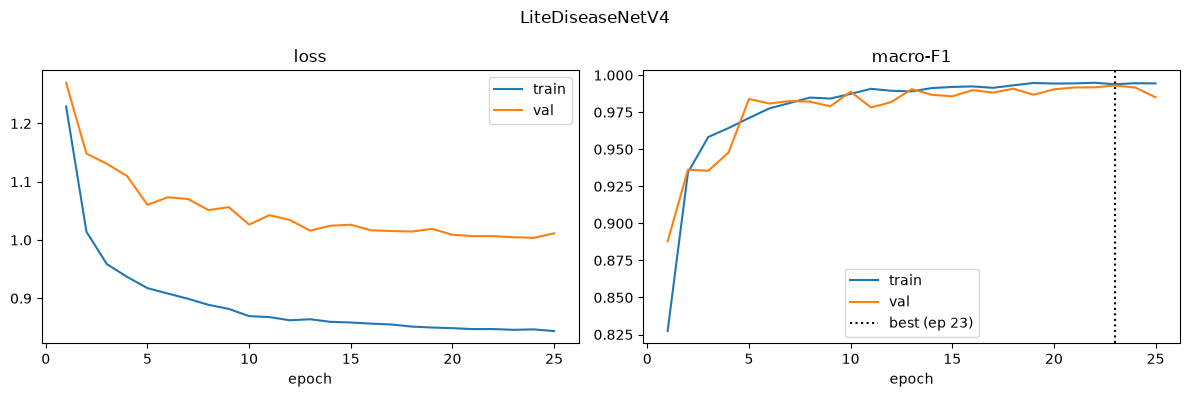

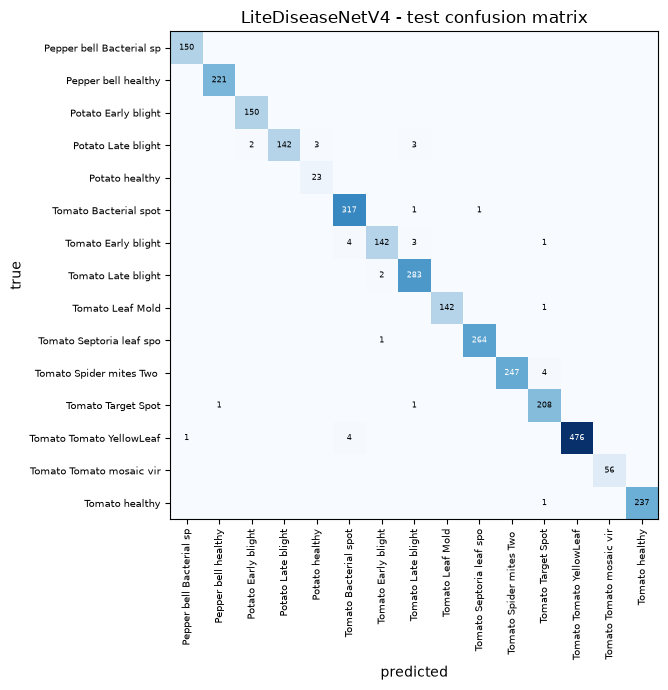

In [4]:
# ---- evaluate the best checkpoint ------------------------------------------- #
MODEL.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE, weights_only=True))
print(f"loaded {BEST_PATH} (epoch {best['epoch']})\n")

store = {}
for split, ld in (("train", train_eval_loader), ("val", val_loader), ("test", test_loader)):
    r = store[split] = run_epoch(MODEL, ld, desc=f"eval {split}")
    print(f"{split:<6} n={r['n']:<6} loss {r['loss']:.4f}  acc {r['accuracy']:.4f}  "
          f"macro-P {r['macro_precision']:.4f}  macro-R {r['macro_recall']:.4f}  "
          f"macro-F1 {r['macro_f1']:.4f}")

print("\n" + classification_report(store["test"]["targets"], store["test"]["preds"],
                                    target_names=CLASS_NAMES, digits=4, zero_division=0))

RESULTS = {
    "model": "litedisease_v4", "arch": "LiteDiseaseNetV4 (mobilenet_v2 dual-branch)",
    "params_total": int(n_total), "seed": SEED, "epochs": EPOCHS,
    "lr_backbone": LR_BACKBONE, "lr_head": LR_HEAD,
    "label_smoothing": LABEL_SMOOTHING, "batch_size": BATCH_SIZE,
    "img_size": IMG_SIZE, "class_weighted": CLASS_WEIGHTS is not None,
    "amp": bool(AMP_ON), "best_epoch": int(best["epoch"]),
    "best_val_macro_f1": round(float(best["val_macro_f1"]), 6),
    "n_classes": N_CLASSES, "class_names": CLASS_NAMES,
    "data_source": "clean (repaired in Part A of crop_disease_pipeline.ipynb)",
    "splits": {s: {k: (round(float(v), 6) if isinstance(v, float) else int(v))
                   for k, v in r.items() if k in
                   ("n", "loss", "accuracy", "macro_precision", "macro_recall", "macro_f1")}
               for s, r in store.items()},
}
(OUT_DIR / "litedisease_v4_results.json").write_text(json.dumps(RESULTS, indent=2))

torch.save({"state_dict": MODEL.state_dict(), "class_names": CLASS_NAMES,
            "img_size": IMG_SIZE, "arch": "LiteDiseaseNetV4",
            "model_key": "litedisease_v4",
            "normalize_mean": MEAN, "normalize_std": STD,
            "test_metrics": RESULTS["splits"]["test"]},
           OUT_DIR / "crop_disease_litedisease_v4.pth")
print("saved litedisease_v4_results.json and crop_disease_litedisease_v4.pth")

log = pd.read_csv(LOG_PATH)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(log["epoch"], log["train_loss"], label="train")
axes[0].plot(log["epoch"], log["val_loss"], label="val")
axes[0].set_title("loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(log["epoch"], log["train_macro_f1"], label="train")
axes[1].plot(log["epoch"], log["val_macro_f1"], label="val")
axes[1].axvline(best["epoch"], ls=":", c="k", label=f"best (ep {best['epoch']})")
axes[1].set_title("macro-F1"); axes[1].set_xlabel("epoch"); axes[1].legend()
fig.suptitle("LiteDiseaseNetV4"); fig.tight_layout()
fig.savefig(OUT_DIR / "litedisease_v4_curves.png", dpi=120)
plt.show()

cm = confusion_matrix(store["test"]["targets"], store["test"]["preds"])
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
short = [c.replace("___", " ").replace("__", " ").replace("_", " ")[:24]
         for c in CLASS_NAMES]
ax.set_xticklabels(short, rotation=90, fontsize=7)
ax.set_yticklabels(short, fontsize=7)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=6,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title("LiteDiseaseNetV4 - test confusion matrix")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
fig.tight_layout()
fig.savefig(OUT_DIR / "litedisease_v4_confusion_test.png", dpi=120)
plt.show()

In [6]:
# ---- test-time augmentation: average plain + horizontal-flip predictions ---- #
# Free accuracy: no retraining, 2x inference cost. Uses the best checkpoint
# already loaded in the evaluation cell above.
MODEL.eval()
plain_probs, tta_probs, targets_l = [], [], []
with torch.no_grad():
    for x, y in tqdm(test_loader, desc="TTA test", leave=False, unit="b"):
        x = x.to(DEVICE)
        p1 = MODEL(x).softmax(1)
        p2 = MODEL(torch.flip(x, dims=[3])).softmax(1)
        plain_probs.append(p1.cpu()); tta_probs.append((p1 + p2).cpu())
        targets_l.append(y)

targets_np = torch.cat(targets_l).numpy()
plain_pred = torch.cat(plain_probs).argmax(1).numpy()
tta_pred = torch.cat(tta_probs).argmax(1).numpy()

for name, pred in (("plain", plain_pred), ("TTA", tta_pred)):
    acc = accuracy_score(targets_np, pred)
    p, r, f1, _ = precision_recall_fscore_support(targets_np, pred,
                                                  average="macro", zero_division=0)
    print(f"{name:6} acc {acc*100:.2f}%  macro-P {p*100:.2f}%  "
          f"macro-R {r*100:.2f}%  macro-F1 {f1*100:.2f}%")
fixed = int(((plain_pred != targets_np) & (tta_pred == targets_np)).sum())
broken = int(((plain_pred == targets_np) & (tta_pred != targets_np)).sum())
print(f"TTA fixed {fixed} predictions, broke {broken}")

# record next to the plain numbers so the results file carries both
p, r, f1, _ = precision_recall_fscore_support(targets_np, tta_pred,
                                              average="macro", zero_division=0)
RESULTS["splits"]["test_tta"] = {
    "n": int(len(targets_np)),
    "accuracy": round(float(accuracy_score(targets_np, tta_pred)), 6),
    "macro_precision": round(float(p), 6), "macro_recall": round(float(r), 6),
    "macro_f1": round(float(f1), 6),
}
(OUT_DIR / "litedisease_v4_results.json").write_text(json.dumps(RESULTS, indent=2))
print("test_tta block written to litedisease_v4_results.json")


plain  acc 98.90%  macro-P 98.34%  macro-R 98.86%  macro-F1 98.57%
TTA    acc 99.16%  macro-P 98.57%  macro-R 99.18%  macro-F1 98.85%
TTA fixed 9 predictions, broke 1
test_tta block written to litedisease_v4_results.json


In [5]:
# ---- compare with SqueezeNet ------------------------------------------------ #
sq_path = OUT_DIR / "results_squeezenet1_1.json"
if sq_path.is_file():
    sq = json.loads(sq_path.read_text())
    rows = []
    for name, res in (("SqueezeNet 1.1", sq), ("LiteDiseaseNetV4", RESULTS)):
        t = res["splits"]["test"]
        rows.append({"model": name, "params": f"{res['params_total']:,}",
                     "test_acc": round(t["accuracy"], 4),
                     "test_macro_f1": round(t["macro_f1"], 4),
                     "best_epoch": res["best_epoch"]})
    print(pd.DataFrame(rows).to_string(index=False))
    print("\nnote: recipes differ (epochs/LR/label smoothing), so this is an informal "
          "comparison, not a row for the locked seven-way table.")
else:
    print("results_squeezenet1_1.json not found - run the pipeline notebook for the baseline")

           model    params  test_acc  test_macro_f1  best_epoch
  SqueezeNet 1.1   730,191    0.9796         0.9795          18
LiteDiseaseNetV4 5,438,786    0.9890         0.9857          23

note: recipes differ (epochs/LR/label smoothing), so this is an informal comparison, not a row for the locked seven-way table.


## Try it on your own photo

Copy photos into the `my_photos/` folder next to this notebook, then run the cell.
Requires the **config and model cells above to have been run once** in this kernel
(they build the model; the cell below loads the trained weights itself, so no
training is needed). Predictions use flip-TTA, same as the reported best numbers.


In [ ]:
# Predict every image in my_photos/ with the best checkpoint + flip TTA.
assert "MODEL" in dir(), "run the config and model cells above first"
MODEL.load_state_dict(torch.load(OUT_DIR / "litedisease_v4_best.pth",
                                 map_location=DEVICE, weights_only=True))
MODEL.eval()

PHOTO_DIR = Path("my_photos")
PHOTO_DIR.mkdir(exist_ok=True)
_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
_photos = sorted(p for p in PHOTO_DIR.iterdir()
                 if p.suffix.lower() in _exts and not p.name.startswith("prediction"))
if not _photos:
    print(f"No photos found. Copy leaf photos into: {PHOTO_DIR.resolve()} and rerun.")

_short = [n.replace("___", " ").replace("__", " ").replace("_", " ")[:28]
          for n in CLASS_NAMES]
for _f in _photos:
    try:
        _img = Image.open(_f).convert("RGB")
    except Exception as e:
        print(f"{_f.name}: not an image ({e})")
        continue
    _x = eval_tf(_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        _prob = (MODEL(_x).softmax(1) + MODEL(torch.flip(_x, dims=[3])).softmax(1))[0]
        _prob = (_prob / _prob.sum()).cpu().numpy()
    _top = np.argsort(_prob)[::-1][:5]

    _fig, _ax = plt.subplots(1, 2, figsize=(12, 4.6),
                             gridspec_kw={"width_ratios": [1, 1.5]})
    _ax[0].imshow(_img)
    _ax[0].axis("off")
    _ax[0].set_title(_f.name[:40])
    _ax[1].barh([_short[i] for i in _top][::-1], _prob[_top][::-1],
                color=["#c7d9f1"] * 4 + ["#1f6fb4"])
    _ax[1].set_xlim(0, 1)
    _ax[1].set_xlabel("probability")
    _ax[1].set_title(f"LiteDiseaseNetV4+TTA: {CLASS_NAMES[_top[0]]}  "
                     f"({_prob[_top[0]]:.1%})")
    for _i, _v in enumerate(_prob[_top][::-1]):
        _ax[1].text(_v + 0.01, _i, f"{_v:.1%}", va="center", fontsize=9)
    _fig.tight_layout()
    plt.show()
    print(f"{_f.name} -> {CLASS_NAMES[_top[0]]}  {_prob[_top[0]]:.1%}")
    if _prob[_top[0]] < 0.5:
        print("  low confidence - photo is far from the studio-style training data")
